<a href="https://colab.research.google.com/github/stefdeg145/sma-rul-twin/blob/main/01_sma_synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wrote sma_synthetic.csv  (92,746 rows, 5 conditions)
              delta_eps_p     Nf
condition_id                    
0                   0.010  50000
1                   0.015  22222
2                   0.020  12500
3                   0.030   5555
4                   0.045   2469
Wrote sma_synthetic.png


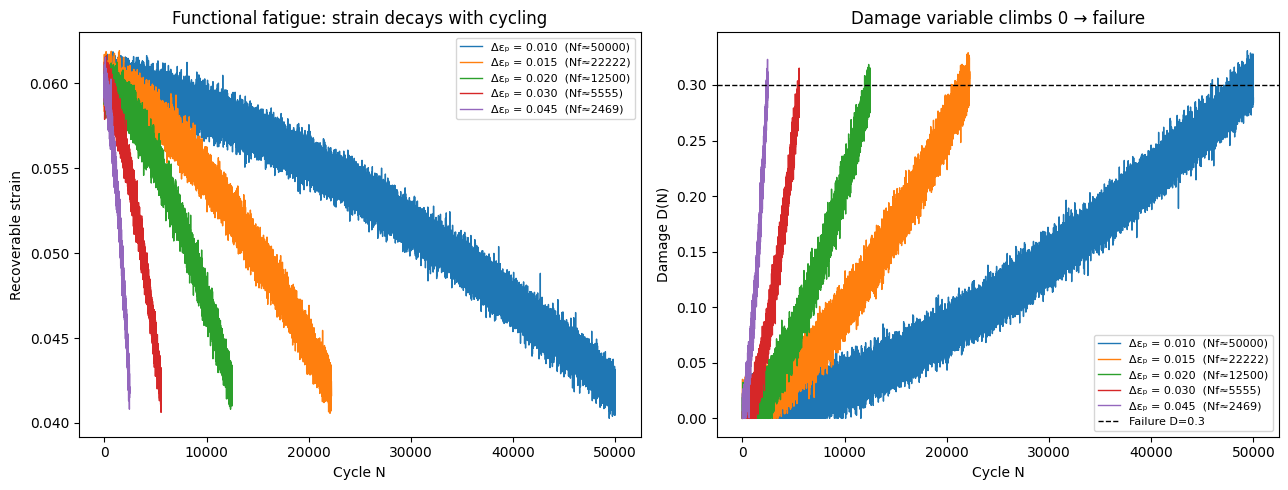

In [ ]:
"""
sma_synthetic_data.py
---------------------------------
Generates synthetic SMA "functional fatigue" data and computes the damage
variable D(N). This gives you something to train an LSTM on TODAY, before any
real dataset arrives.

Physics baked in:
  - Coffin-Manson:        N_f = C * (delta_eps_p)^(-m)
  - Functional fatigue:   recoverable strain decays as cycles accumulate,
                          approaching failure as N -> N_f
  - Damage variable:      D(N) = 1 - eps_rec(N) / eps_rec(1)   (monotone, 0 -> 1)

Output:
  - A CSV (sma_synthetic.csv) with one row per (condition, cycle)
  - A multi-panel plot showing strain decay and D(N) trajectories

Run in Google Colab or anywhere with numpy/pandas/matplotlib.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---- Coffin-Manson constants (illustrative; you'll learn these from data later)
# Tuned so lifetimes land in the realistic 1k-50k cycle range for SMA actuators.
C = 5.0            # scaling constant
m = 2.0            # exponent

# ---- Loading conditions: each is a different plastic strain range (amplitude)
#      Bigger strain amplitude -> shorter life. That's the physics.
strain_ranges = [0.010, 0.015, 0.020, 0.030, 0.045]   # delta_eps_p
NOISE_LEVEL = 0.01      # measurement noise on recoverable strain
D_FAIL = 0.30           # 30% loss of recoverable strain = "failed" actuator


def cycles_to_failure(delta_eps_p):
    """Coffin-Manson: how many cycles until this amplitude kills the actuator."""
    return C * (delta_eps_p ** (-m))


def simulate_condition(delta_eps_p, cond_id):
    """Simulate one specimen cycled at a fixed strain amplitude until failure."""
    Nf = int(cycles_to_failure(delta_eps_p))
    eps_rec_initial = 0.06                      # initial recoverable strain (6%)

    cycles = np.arange(1, Nf + 1)

    # Functional fatigue decay: recoverable strain drops toward the failure
    # threshold as N approaches Nf. Smooth, accelerating loss near end of life.
    fraction_life = cycles / Nf
    decay = D_FAIL * (fraction_life ** 1.5)     # damage grows faster late in life
    eps_rec_clean = eps_rec_initial * (1.0 - decay)

    # Add realistic measurement noise
    noise = rng.normal(0, NOISE_LEVEL * eps_rec_initial, size=Nf)
    eps_rec = eps_rec_clean + noise

    # Damage variable (computed from the FIRST cycle, per the brief's definition)
    D = 1.0 - eps_rec / eps_rec[0]
    D = np.clip(D, 0.0, 1.0)

    return pd.DataFrame({
        "condition_id": cond_id,
        "delta_eps_p": delta_eps_p,
        "Nf_true": Nf,
        "cycle": cycles,
        "eps_recoverable": eps_rec,
        "damage_D": D,
    })


# ---- Generate the full dataset
frames = [simulate_condition(s, i) for i, s in enumerate(strain_ranges)]
df = pd.concat(frames, ignore_index=True)
df.to_csv("sma_synthetic.csv", index=False)
print(f"Wrote sma_synthetic.csv  ({len(df):,} rows, "
      f"{df.condition_id.nunique()} conditions)")
print(df.groupby("condition_id")
        .agg(delta_eps_p=("delta_eps_p", "first"),
             Nf=("Nf_true", "first"))
        .to_string())

# ---- Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for cid, g in df.groupby("condition_id"):
    label = f"Δεₚ = {g.delta_eps_p.iloc[0]:.3f}  (Nf≈{g.Nf_true.iloc[0]})"
    ax1.plot(g.cycle, g.eps_recoverable, lw=1, label=label)
    ax2.plot(g.cycle, g.damage_D, lw=1, label=label)

ax1.set(xlabel="Cycle N", ylabel="Recoverable strain",
        title="Functional fatigue: strain decays with cycling")
ax2.axhline(D_FAIL, ls="--", color="k", lw=1, label=f"Failure D={D_FAIL}")
ax2.set(xlabel="Cycle N", ylabel="Damage D(N)",
        title="Damage variable climbs 0 → failure")
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig("sma_synthetic.png", dpi=120)
print("Wrote sma_synthetic.png")


In [ ]:
from google.colab import files
files.download("sma_synthetic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("sma_synthetic.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>